# L12. LSTM Basics

이번 실습에서는 RNN과 비슷한 문자 시퀀스 분류 문제를 `nn.LSTM`으로 풀어본다. LSTM은 hidden state와 cell state를 함께 사용해서 기본 RNN보다 긴 의존성을 더 안정적으로 다룰 수 있다.

- `nn.LSTM`의 출력 형태를 확인한다.
- 마지막 hidden state로 many-to-one 분류를 구현한다.
- RNN과 LSTM의 학습 곡선을 비교한다.
- 연습문제에서는 hidden size, epoch 수, 입력 차원, 2-layer LSTM, LSTM이 유리한 문제를 확인한다.

## 1. 데이터 준비

RNN 실습과 같은 규칙을 사용하되 sequence 길이를 6으로 늘린다. 모음 수가 자음 수보다 많거나 같으면 class 1, 아니면 class 0이다.

In [1]:
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
chars = list("abcdexiou")
vowels = set("aeiou")

samples = [
    "aeiiou", "aeexou", "ioeaau", "eiooua",
    "bcdexd", "bcddxb", "ccdbbd", "ddcbbx",
    "abciou", "bcdaex", "cdeiou", "bbbaix",
    "aeabio", "ccddee", "iouabc", "bbbccd",
]


def make_labels(sample_list):
    labels = []
    for s in sample_list:
        vowel_count = sum(ch in vowels for ch in s)
        consonant_count = len(s) - vowel_count
        labels.append(1 if vowel_count >= consonant_count else 0)
    return torch.tensor(labels, dtype=torch.long)


def encode_string(s, char_list):
    char2idx = {ch: i for i, ch in enumerate(char_list)}
    x = torch.zeros(len(s), len(char_list))
    for t, ch in enumerate(s):
        x[t, char2idx[ch]] = 1.0
    return x


def make_dataset(sample_list, char_list):
    encoded = torch.stack([encode_string(s, char_list) for s in sample_list])
    y = make_labels(sample_list)
    return encoded.float(), y


encoded, y = make_dataset(samples, chars)

print("chars:", chars)
print("samples:", samples)
print("labels :", y.tolist())
print("encoded shape:", tuple(encoded.shape))
print("label shape  :", tuple(y.shape))

chars: ['a', 'b', 'c', 'd', 'e', 'x', 'i', 'o', 'u']
samples: ['aeiiou', 'aeexou', 'ioeaau', 'eiooua', 'bcdexd', 'bcddxb', 'ccdbbd', 'ddcbbx', 'abciou', 'bcdaex', 'cdeiou', 'bbbaix', 'aeabio', 'ccddee', 'iouabc', 'bbbccd']
labels : [1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0]
encoded shape: (16, 6, 9)
label shape  : (16,)


## 2. `nn.LSTM` 출력 확인

LSTM은 `output, (h_n, c_n)`을 반환한다. `h_n`은 hidden state, `c_n`은 cell state이다.

output shape: (16, 6, 8)
h_n shape   : (1, 16, 8)
c_n shape   : (1, 16, 8)


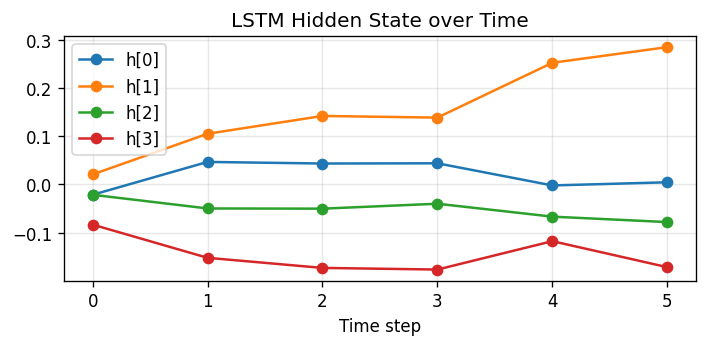

In [3]:
lstm = nn.LSTM(input_size=len(chars), hidden_size=8, batch_first=True)
output, (h_n, c_n) = lstm(encoded)

print("output shape:", tuple(output.shape))  # batch, seq_len, hidden_size
print("h_n shape   :", tuple(h_n.shape))    # num_layers, batch, hidden_size
print("c_n shape   :", tuple(c_n.shape))    # num_layers, batch, hidden_size

plt.figure(figsize=(6, 3))
for i in range(4):
    plt.plot(output[0, :, i].detach().numpy(), marker="o", label=f"h[{i}]")
plt.title("LSTM Hidden State over Time")
plt.xlabel("Time step")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 3. LSTM 분류 모델 만들기

마지막 layer의 마지막 hidden state인 `h_n[-1]`을 사용해서 문자열 전체의 class를 예측한다.

In [4]:
def make_loader(encoded_tensor, label_tensor, batch_size=4, seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)
    dataset = TensorDataset(encoded_tensor, label_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)


class CharLSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        logits = self.fc(last_hidden)
        return logits


class CharRNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        output, h_n = self.rnn(x)
        return self.fc(h_n[-1])


def train_classifier(model, encoded_tensor, label_tensor, epochs=80, lr=1e-2, batch_size=4):
    model = model.to(device)
    encoded_tensor = encoded_tensor.to(device)
    label_tensor = label_tensor.to(device)

    train_loader = make_loader(encoded_tensor, label_tensor, batch_size=batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += xb.size(0)

        loss_history.append(total_loss / total_count)
        acc_history.append(total_correct / total_count)

    return loss_history, acc_history


def evaluate_classifier(model, encoded_tensor, label_tensor, sample_list):
    model.eval()
    with torch.no_grad():
        logits = model(encoded_tensor.to(device))
        preds = logits.argmax(dim=1).cpu()

    for s, target, pred in zip(sample_list, label_tensor.tolist(), preds.tolist()):
        print(f"{s:>8s} -> target={target}, pred={pred}")


torch.manual_seed(SEED)
model = CharLSTMClassifier(input_dim=len(chars), hidden_dim=16, num_classes=2)
print(model)

loss_history, acc_history = train_classifier(model, encoded, y, epochs=80)
print("final loss:", round(loss_history[-1], 4))
print("final acc :", round(acc_history[-1], 4))

CharLSTMClassifier(
  (lstm): LSTM(9, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=2, bias=True)
)


final loss: 0.0003
final acc : 1.0


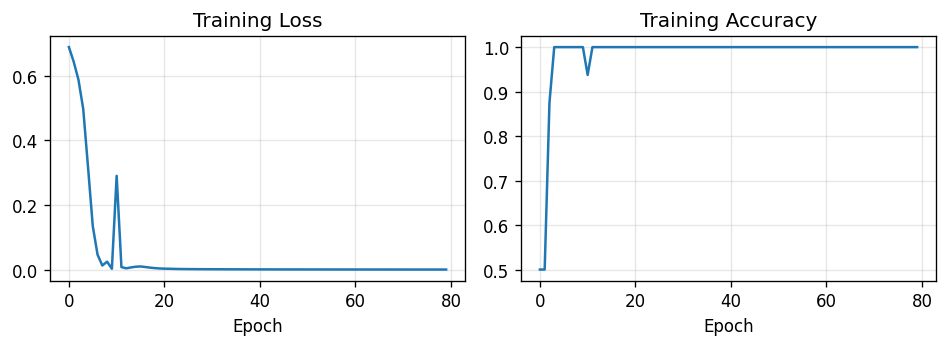

  aeiiou -> target=1, pred=1
  aeexou -> target=1, pred=1
  ioeaau -> target=1, pred=1
  eiooua -> target=1, pred=1
  bcdexd -> target=0, pred=0
  bcddxb -> target=0, pred=0
  ccdbbd -> target=0, pred=0
  ddcbbx -> target=0, pred=0
  abciou -> target=1, pred=1
  bcdaex -> target=0, pred=0
  cdeiou -> target=1, pred=1
  bbbaix -> target=0, pred=0
  aeabio -> target=1, pred=1
  ccddee -> target=0, pred=0
  iouabc -> target=1, pred=1
  bbbccd -> target=0, pred=0


In [5]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(acc_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

evaluate_classifier(model, encoded, y, samples)

## 4. RNN과 LSTM 비교

같은 데이터와 hidden size에서 RNN과 LSTM을 학습시켜 정확도 변화를 비교한다.

RNN final acc : 1.0
LSTM final acc: 1.0


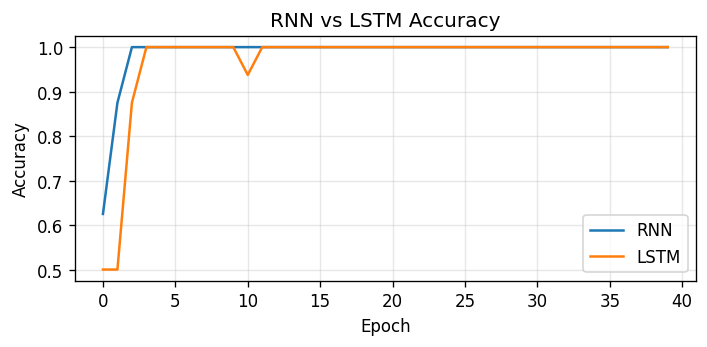

In [6]:
torch.manual_seed(SEED)
rnn_model = CharRNNClassifier(len(chars), 16, 2)
rnn_loss, rnn_acc = train_classifier(rnn_model, encoded, y, epochs=40)

torch.manual_seed(SEED)
lstm_model = CharLSTMClassifier(len(chars), 16, 2)
lstm_loss, lstm_acc = train_classifier(lstm_model, encoded, y, epochs=40)

print("RNN final acc :", round(rnn_acc[-1], 4))
print("LSTM final acc:", round(lstm_acc[-1], 4))

plt.figure(figsize=(6, 3))
plt.plot(rnn_acc, label="RNN")
plt.plot(lstm_acc, label="LSTM")
plt.title("RNN vs LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 1. hidden size를 8, 32로 바꾸고 결과 비교

hidden size는 LSTM이 저장하는 hidden state와 cell state의 차원이다. 값이 커질수록 표현력과 parameter 수가 같이 증가한다.

hidden= 8 | params=  626 | final_loss=0.0005 | final_acc=1.0000
hidden=32 | params= 5570 | final_loss=0.0000 | final_acc=1.0000


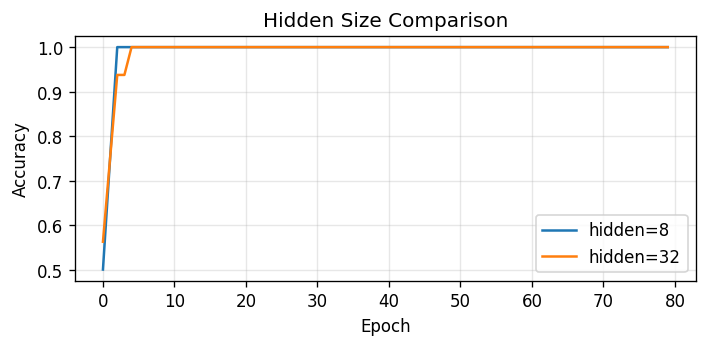

In [7]:
hidden_results = []
hidden_histories = {}

for hidden_dim in [8, 32]:
    torch.manual_seed(SEED)
    candidate = CharLSTMClassifier(len(chars), hidden_dim, 2)
    losses, accs = train_classifier(candidate, encoded, y, epochs=80)
    hidden_results.append(
        {
            "hidden_dim": hidden_dim,
            "final_loss": losses[-1],
            "final_acc": accs[-1],
            "parameters": sum(p.numel() for p in candidate.parameters()),
        }
    )
    hidden_histories[hidden_dim] = (losses, accs)

for row in hidden_results:
    print(
        f"hidden={row['hidden_dim']:>2d} | "
        f"params={row['parameters']:>5d} | "
        f"final_loss={row['final_loss']:.4f} | "
        f"final_acc={row['final_acc']:.4f}"
    )

plt.figure(figsize=(6, 3))
for hidden_dim, (_, accs) in hidden_histories.items():
    plt.plot(accs, label=f"hidden={hidden_dim}")
plt.title("Hidden Size Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 2. epoch 수를 40, 120으로 바꾸고 결과 비교

epoch가 작으면 아직 충분히 수렴하지 못할 수 있고, epoch가 커지면 training data에는 더 잘 맞는다. 이 데이터는 작기 때문에 120 epoch에서는 거의 완전히 외울 수 있다.

epochs= 40 | final_loss=0.0008 | final_acc=1.0000
epochs= 80 | final_loss=0.0003 | final_acc=1.0000
epochs=120 | final_loss=0.0001 | final_acc=1.0000


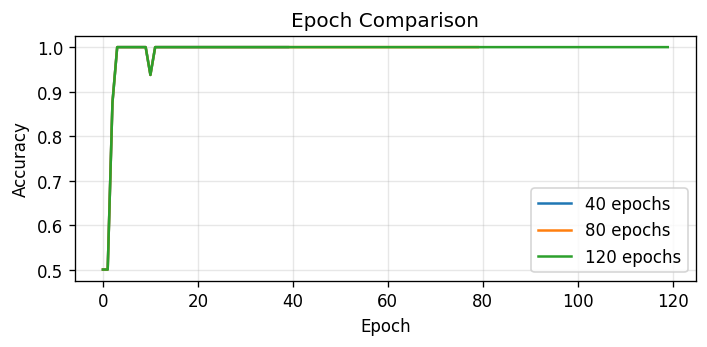

In [8]:
epoch_results = []
epoch_histories = {}

for epochs in [40, 80, 120]:
    torch.manual_seed(SEED)
    candidate = CharLSTMClassifier(len(chars), 16, 2)
    losses, accs = train_classifier(candidate, encoded, y, epochs=epochs)
    epoch_results.append(
        {
            "epochs": epochs,
            "final_loss": losses[-1],
            "final_acc": accs[-1],
        }
    )
    epoch_histories[epochs] = (losses, accs)

for row in epoch_results:
    print(
        f"epochs={row['epochs']:>3d} | "
        f"final_loss={row['final_loss']:.4f} | "
        f"final_acc={row['final_acc']:.4f}"
    )

plt.figure(figsize=(6, 3))
for epochs, (_, accs) in epoch_histories.items():
    plt.plot(accs, label=f"{epochs} epochs")
plt.title("Epoch Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 3. 문자 종류를 더 늘리면 입력 차원이 어떻게 달라지는지 확인

one-hot encoding에서는 문자 종류 수가 그대로 입력 차원이 된다. 문자 3개(`z, y, q`)를 추가하면 입력 차원은 9에서 12로 증가한다.

In [9]:
more_chars = list("abcdexiouzyq")
more_samples = [
    "aeiiou", "aeexou", "ioeaau", "eiooua",
    "bcdexd", "bcddxb", "ccdbbd", "ddcbbx",
    "abciou", "bcdaex", "cdeiou", "bbbaix",
    "zzyyqa", "aeizqy", "iouzyq", "bbbzyq",
]

more_encoded, more_y = make_dataset(more_samples, more_chars)
print("old input dim:", len(chars))
print("new input dim:", len(more_chars))
print("new encoded shape:", tuple(more_encoded.shape))

torch.manual_seed(SEED)
more_model = CharLSTMClassifier(len(more_chars), 16, 2)
more_losses, more_accs = train_classifier(more_model, more_encoded, more_y, epochs=100)
print("new-char final loss:", round(more_losses[-1], 4))
print("new-char final acc :", round(more_accs[-1], 4))
evaluate_classifier(more_model, more_encoded, more_y, more_samples)

old input dim: 9
new input dim: 12
new encoded shape: (16, 6, 12)


new-char final loss: 0.0001
new-char final acc : 1.0
  aeiiou -> target=1, pred=1
  aeexou -> target=1, pred=1
  ioeaau -> target=1, pred=1
  eiooua -> target=1, pred=1
  bcdexd -> target=0, pred=0
  bcddxb -> target=0, pred=0
  ccdbbd -> target=0, pred=0
  ddcbbx -> target=0, pred=0
  abciou -> target=1, pred=1
  bcdaex -> target=0, pred=0
  cdeiou -> target=1, pred=1
  bbbaix -> target=0, pred=0
  zzyyqa -> target=0, pred=0
  aeizqy -> target=1, pred=1
  iouzyq -> target=1, pred=1
  bbbzyq -> target=0, pred=0


## Exercise 4. `nn.LSTM`의 층 수를 2층으로 늘리기

`num_layers=2`를 주면 LSTM이 두 층으로 쌓인다. 이때 `h_n`의 shape은 `(2, batch, hidden_size)`가 되고, 마지막 층의 hidden state는 그대로 `h_n[-1]`로 꺼내면 된다.

1-layer params: 1762
2-layer params: 3938
1-layer final loss/acc: 0.0003 1.0
2-layer final loss/acc: 0.0001 1.0
2-layer h_n shape: (2, 16, 16)
2-layer c_n shape: (2, 16, 16)


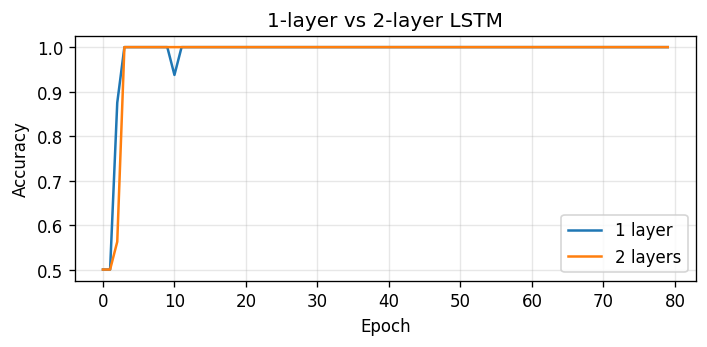

In [10]:
torch.manual_seed(SEED)
one_layer_model = CharLSTMClassifier(len(chars), 16, 2, num_layers=1)
one_losses, one_accs = train_classifier(one_layer_model, encoded, y, epochs=80)

torch.manual_seed(SEED)
two_layer_model = CharLSTMClassifier(len(chars), 16, 2, num_layers=2)
two_losses, two_accs = train_classifier(two_layer_model, encoded, y, epochs=80)

print("1-layer params:", sum(p.numel() for p in one_layer_model.parameters()))
print("2-layer params:", sum(p.numel() for p in two_layer_model.parameters()))
print("1-layer final loss/acc:", round(one_losses[-1], 4), round(one_accs[-1], 4))
print("2-layer final loss/acc:", round(two_losses[-1], 4), round(two_accs[-1], 4))

demo_lstm = nn.LSTM(len(chars), 16, num_layers=2, batch_first=True)
demo_output, (demo_h_n, demo_c_n) = demo_lstm(encoded)
print("2-layer h_n shape:", tuple(demo_h_n.shape))
print("2-layer c_n shape:", tuple(demo_c_n.shape))

plt.figure(figsize=(6, 3))
plt.plot(one_accs, label="1 layer")
plt.plot(two_accs, label="2 layers")
plt.title("1-layer vs 2-layer LSTM")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 5. RNN보다 LSTM이 더 유리한 sequence 문제 예시

LSTM은 cell state와 gate 구조를 사용하므로 긴 sequence에서 오래된 정보를 비교적 잘 유지한다. 그래서 다음과 같은 문제에서 기본 RNN보다 유리할 수 있다.

- 긴 문장의 감성 분석: 문장 앞부분의 부정어가 뒤쪽 표현의 의미를 바꾸는 경우가 있다.
- 장기 시계열 예측: 전력 사용량, 주가, 기상 데이터처럼 과거 패턴이 긴 시간 뒤에도 영향을 줄 수 있다.
- 긴 로그 데이터 이상 탐지: 초반 이벤트와 후반 이벤트의 조합이 이상 여부를 결정할 수 있다.
- 음악/문장 생성: 앞에서 만든 흐름을 오래 기억해야 자연스러운 sequence를 만들 수 있다.

정리하면 짧고 단순한 의존성은 RNN으로도 충분하지만, 긴 기간의 정보 보존이 중요하면 LSTM이 더 적합하다.